# Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load and Display Coins Image

Image shape: (203, 248)
Minimum intensity: 11
Maximum intensity: 255


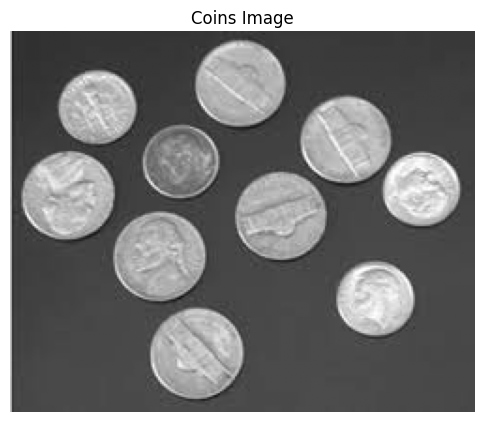

In [2]:
# Read coins image as grayscale
coins = cv2.imread("coins.png", cv2.IMREAD_GRAYSCALE)

# Check image
print("Image shape:", coins.shape)
print("Minimum intensity:", coins.min())
print("Maximum intensity:", coins.max())

# Display image
plt.figure(figsize=(6, 5))
plt.imshow(coins, cmap="gray", vmin=0, vmax=255)
plt.title("Coins Image")
plt.axis("off")
plt.show()

# Compute Histogram

In [3]:
# Flatten image into a 1D array
pixels = coins.ravel()

# Compute histogram
histogram = np.bincount(pixels, minlength=256)

# Total number of pixels
N = len(pixels)

# Intensity levels
intensities = np.arange(256)

print("Total number of pixels:", N)

Total number of pixels: 50344


# Compute Otsu Optimal Threshold

In [4]:
# Otsu's Method
# Find threshold that minimizes within-class variance

within_class_variances = []

for th in range(256):

    # Class 0: pixels <= threshold
    class0 = pixels[pixels <= th]

    # Class 1: pixels > threshold
    class1 = pixels[pixels > th]

    # If one of the classes is empty, skip this threshold
    if len(class0) == 0 or len(class1) == 0:
        within_class_variances.append(np.inf)
        continue

    # Class probabilities
    w0 = len(class0) / N
    w1 = len(class1) / N

    # Class variances
    var0 = np.var(class0)
    var1 = np.var(class1)

    # Within-class variance
    sigma_intra = w0 * var0 + w1 * var1

    within_class_variances.append(sigma_intra)

# Convert to numpy array
within_class_variances = np.array(within_class_variances)

# Find threshold that minimizes within-class variance
optimal_threshold = np.argmin(within_class_variances)

print("Optimal Otsu Threshold =", optimal_threshold)
print("Minimum Within-Class Variance =",
      within_class_variances[optimal_threshold])

Optimal Otsu Threshold = 125
Minimum Within-Class Variance = 265.1024571148033


# Plot Within-Class Variance

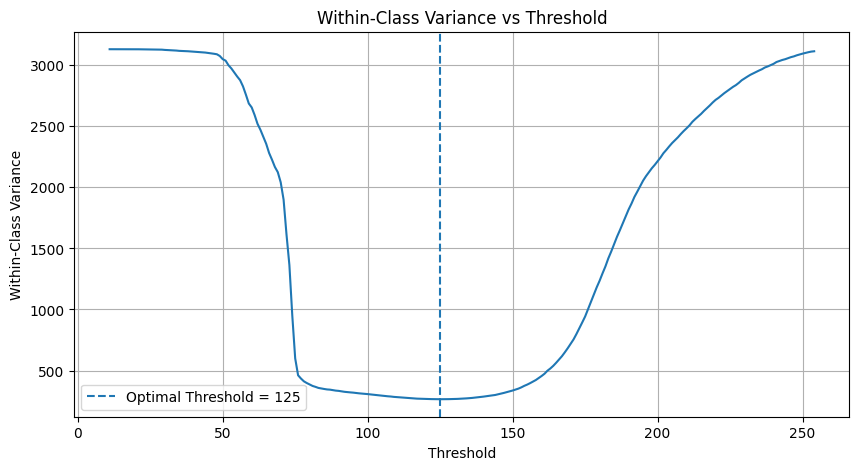

In [5]:
plt.figure(figsize=(10, 5))

plt.plot(intensities, within_class_variances)

plt.axvline(
    optimal_threshold,
    linestyle="--",
    label=f"Optimal Threshold = {optimal_threshold}"
)

plt.xlabel("Threshold")
plt.ylabel("Within-Class Variance")
plt.title("Within-Class Variance vs Threshold")
plt.legend()
plt.grid(True)

plt.show()

# Binarize Image Using Otsu Threshold

In [6]:
# Binarize the image using the optimal threshold

binary_image = np.where(
    coins > optimal_threshold,
    255,
    0
).astype(np.uint8)

print("Optimal Threshold =", optimal_threshold)

Optimal Threshold = 125


# Display Original and Binarized Images

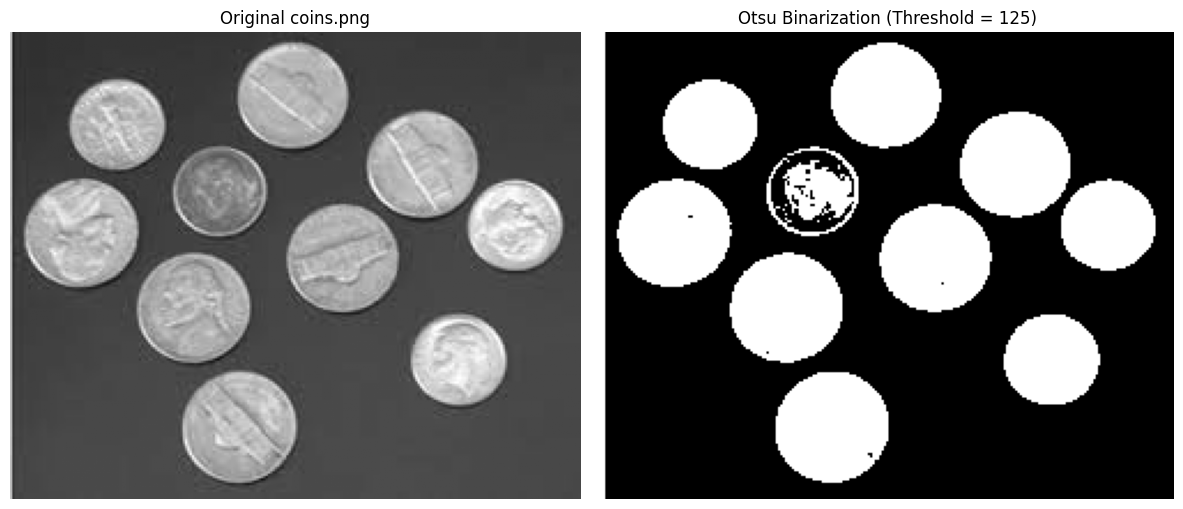

In [7]:
plt.figure(figsize=(12, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(coins, cmap="gray", vmin=0, vmax=255)
plt.title("Original coins.png")
plt.axis("off")

# Binarized image
plt.subplot(1, 2, 2)
plt.imshow(binary_image, cmap="gray", vmin=0, vmax=255)
plt.title(f"Otsu Binarization (Threshold = {optimal_threshold})")
plt.axis("off")

plt.tight_layout()
plt.show()